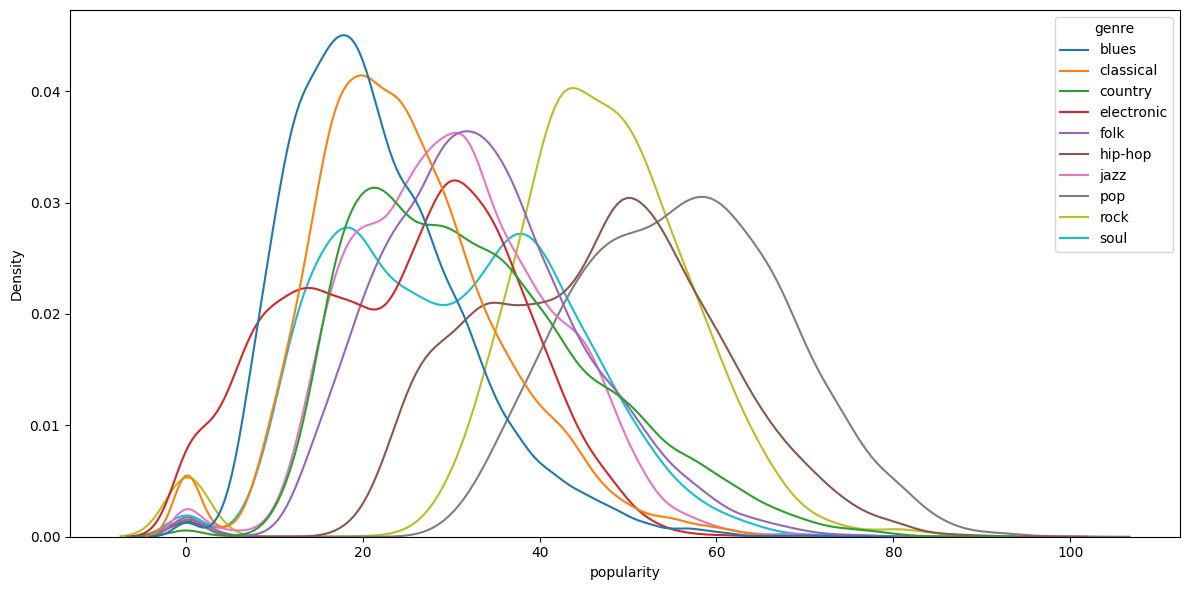

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("million_spotify_data.csv")

selected_genres = ["rock", "electronic", "hiphop", "folk","hip-hop","pop", "classical", "jazz", "country", "soul", "blues"]
df = df[df["genre"].isin(selected_genres)]
df_plot = df[["popularity", "genre"]]

# Create plot
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df_plot,
    x="popularity",
    hue="genre",
    fill=False,
    common_norm=False
)

plt.xlabel("popularity")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

Figures Models Without Year

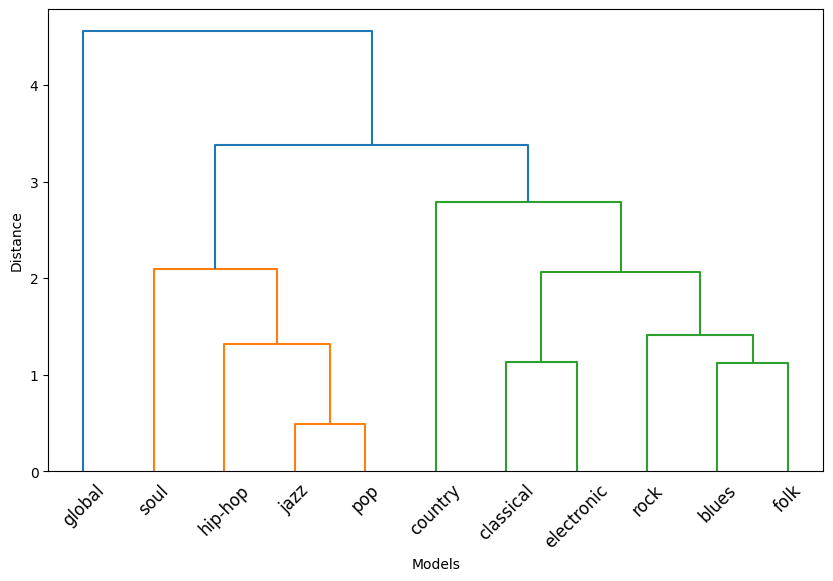

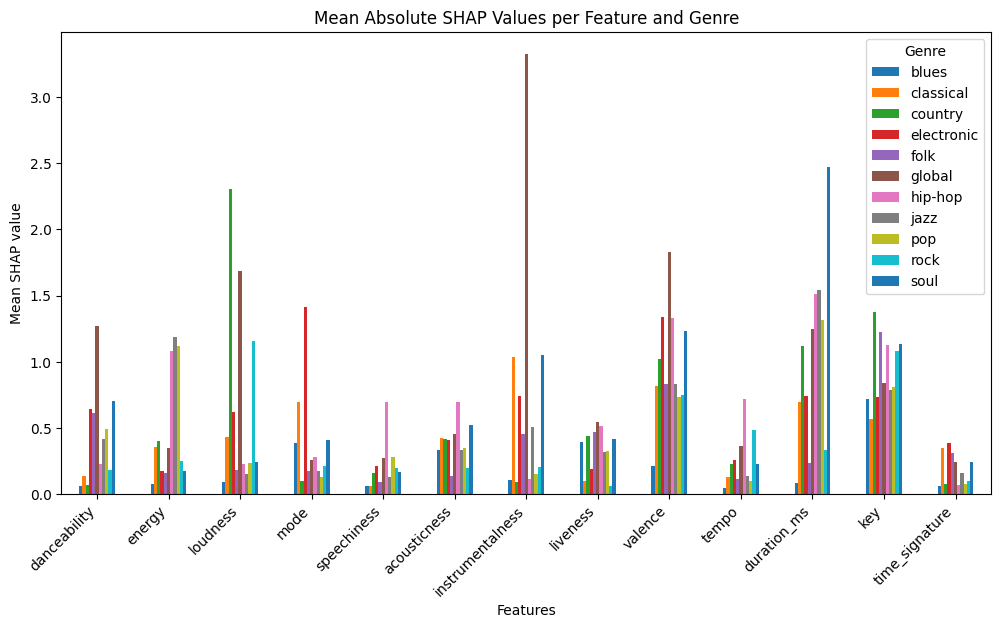

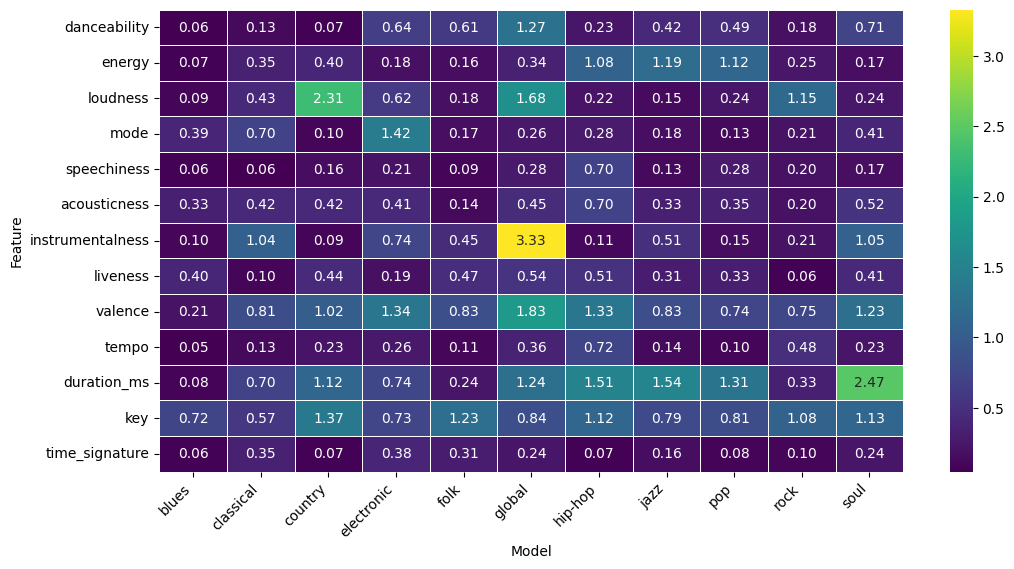

In [14]:
df_noyear = pd.read_csv("Results/results_noyear.csv")

shap_cols = [col for col in df_noyear.columns if col.startswith("shap_")]

#Adds the mean shap value of each each feature per genre to a df
noyear_importance = (df_noyear.groupby("model")[shap_cols].apply(lambda x: x.abs().mean()))

#makes a aggregate feature for key and time_signature 
noyear_importance["shap_key"] = noyear_importance[[col for col in noyear_importance.columns if col.startswith("shap_key")]].sum(axis=1)
noyear_importance["shap_time_signature"] = noyear_importance[[col for col in noyear_importance.columns if col.startswith("shap_time_signature")]].sum(axis=1)

# Drop the individual dummy columns
drop_cols = [col for col in noyear_importance.columns if col.startswith("shap_key_") or col.startswith("shap_time_signature_")]
noyear_importance = noyear_importance.drop(columns=drop_cols)

# Dendrogram
Z = linkage(noyear_importance, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z,labels=noyear_importance.index.tolist(),leaf_rotation=45)
plt.xlabel("Models")
plt.ylabel("Distance")
plt.show()

# Bar plot
noyear_importance.T.plot(kind="bar", figsize=(12, 6))
plt.title("Mean Absolute SHAP Values per Feature and Genre")
plt.ylabel("Mean SHAP value")
plt.xlabel("Features")

#Removes shap_ from the feature labels
locs, labels = plt.xticks()
new_labels = [label.get_text().replace("shap_", "") for label in labels]

plt.xticks(locs, new_labels, rotation=45, ha='right')
plt.legend(title="Genre")
plt.show()

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    noyear_importance.T,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    yticklabels=[col.replace("shap_", "") for col in noyear_importance.columns]
)
plt.ylabel("Feature")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.show()

Figures Models With Year

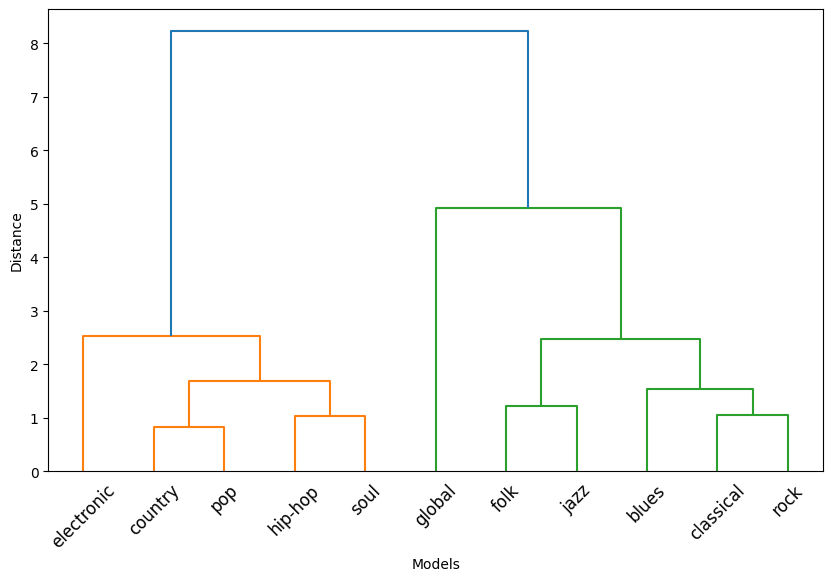

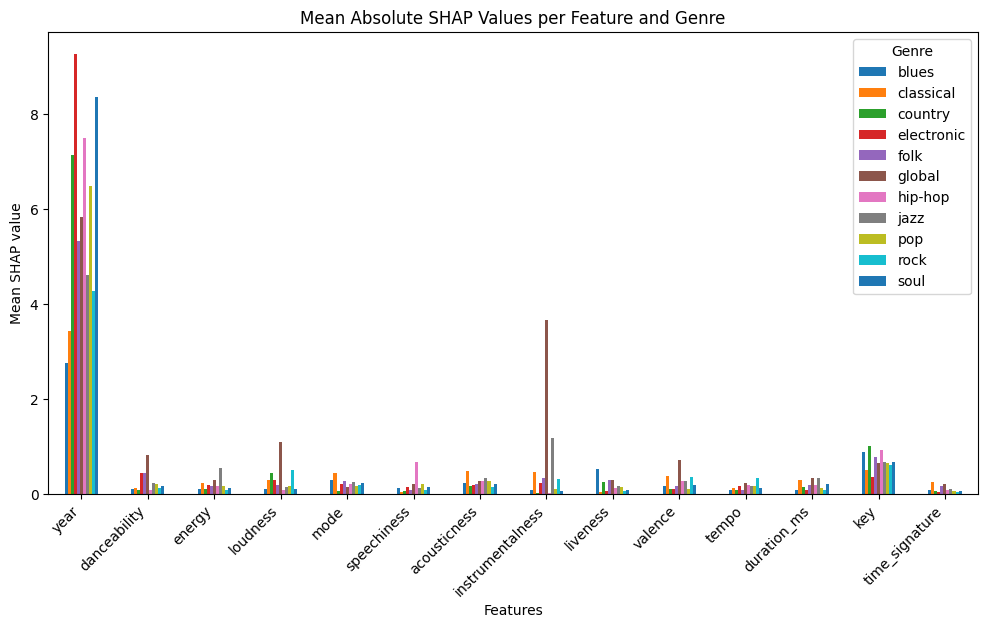

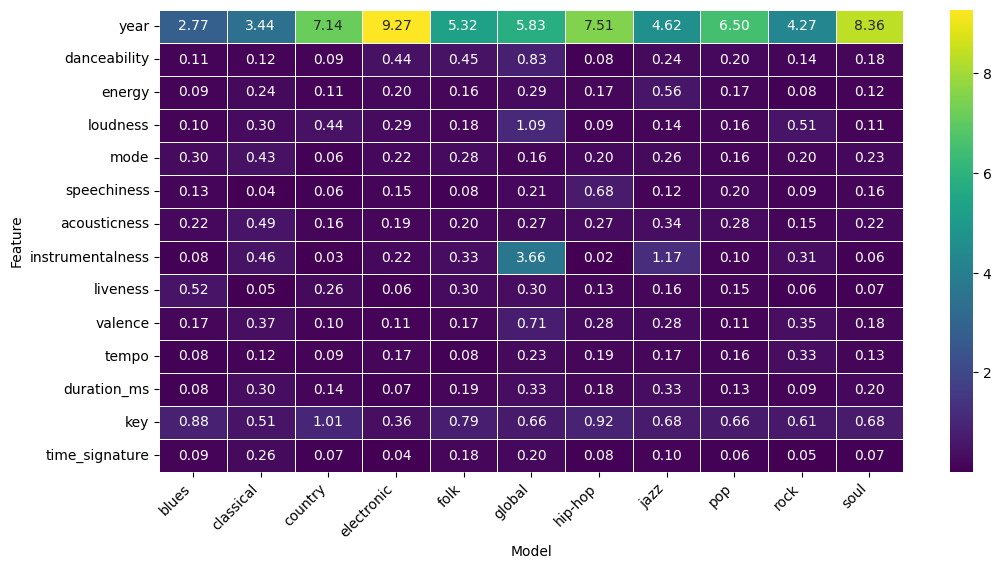

In [16]:
df_withyear = pd.read_csv("Results/results_withyear.csv")

shap_cols = [col for col in df_withyear.columns if col.startswith("shap_")]

#Adds the mean shap value of each each feature per genre to a df
withyear_importance = (df_withyear.groupby("model")[shap_cols].apply(lambda x: x.abs().mean()))

#makes a aggregate feature for key and time_signature 
withyear_importance["shap_key"] = withyear_importance[[col for col in withyear_importance.columns if col.startswith("shap_key")]].sum(axis=1)
withyear_importance["shap_time_signature"] = withyear_importance[[col for col in withyear_importance.columns if col.startswith("shap_time_signature")]].sum(axis=1)

# Drop the individual dummy columns
drop_cols = [col for col in withyear_importance.columns if col.startswith("shap_key_") or col.startswith("shap_time_signature_")]
withyear_importance = withyear_importance.drop(columns=drop_cols)

# Dendrogram ward linkage 
Z = linkage(withyear_importance, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z,labels=withyear_importance.index.tolist(),leaf_rotation=45)
plt.xlabel("Models")
plt.ylabel("Distance")
plt.show()

# Bar plot
withyear_importance.T.plot(kind="bar", figsize=(12, 6))
plt.title("Mean Absolute SHAP Values per Feature and Genre")
plt.ylabel("Mean SHAP value")
plt.xlabel("Features")

#Removes shap_ from the feature labels
locs, labels = plt.xticks()
new_labels = [label.get_text().replace("shap_", "") for label in labels]

plt.xticks(locs, new_labels, rotation=45, ha='right')
plt.legend(title="Genre")
plt.show()

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    withyear_importance.T,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    yticklabels=[col.replace("shap_", "") for col in withyear_importance.columns]
)
plt.ylabel("Feature")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.show()

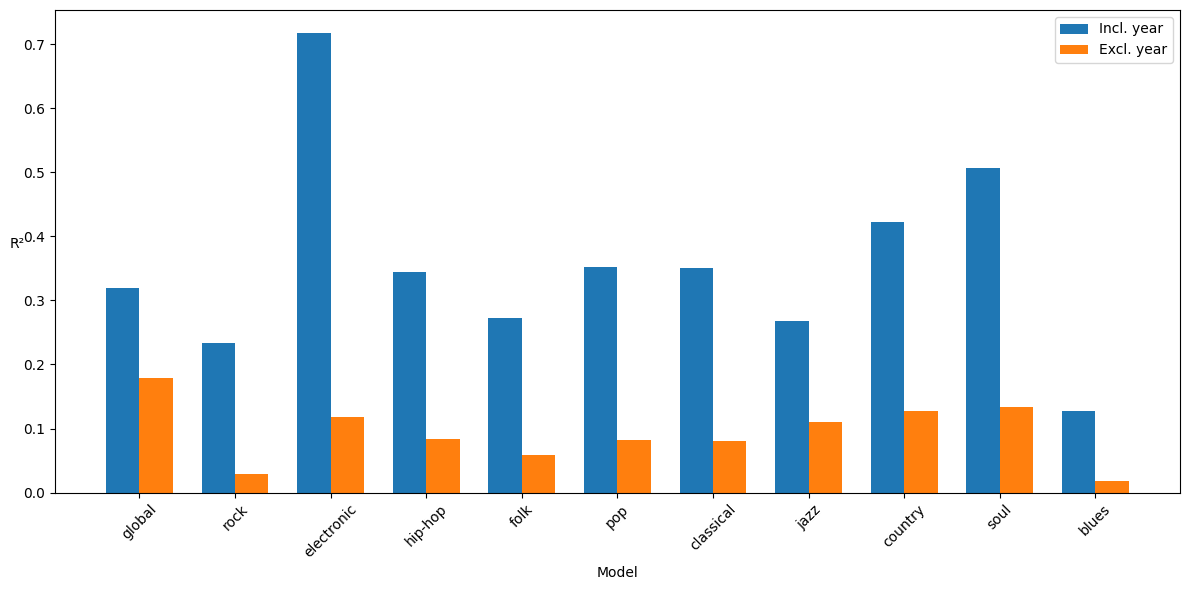

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_with = pd.read_csv("Results/results_withyear.csv")
df_no   = pd.read_csv("Results/results_noyear.csv")

df_with = df_with[["model", "R2"]]
df_no   = df_no[["model", "R2"]]
df = df_with.merge(df_no, on="model", suffixes=("_with", "_no"))

#Moves Global to first position
df = pd.concat([
    df[df["model"] == "global"],
    df[df["model"] != "global"]
])

x = np.arange(len(df["model"]))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df["R2_with"], width, label="Incl. year")
plt.bar(x + width/2, df["R2_no"],   width, label="Excl. year")
plt.xlabel("Model")
plt.ylabel("R²", rotation = 0)
plt.xticks(x, df["model"], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()